In [152]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn import tree 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [153]:
dataset = pd.read_csv("./company_pay.csv")
dataset.head()

,Company,Job,Degree,Salary_100K
0,Google,programmer,bechelors,0
1,Google,sales executive,masters,1
2,Google,programmer,masters,1
3,Google,sales executive,bechelors,0
4,Google,business manager,masters,1


In [154]:
X = dataset.drop(columns="Salary_100K")
y = dataset["Salary_100K"]

In [155]:
X.head()

,Company,Job,Degree
0,Google,programmer,bechelors
1,Google,sales executive,masters
2,Google,programmer,masters
3,Google,sales executive,bechelors
4,Google,business manager,masters


In [156]:
y[:5]

0    0
1    1
2    1
3    0
4    1
Name: Salary_100K, dtype: int64

#### Data Standerd
This data contains some textual data for company, job and degree. but we need local numeric data in order to train the model. Therefore I am using LabelEncoder To conver text data into number.
I could also use Pandas default function like

```python
dataset["Company"] = dataset["Company"].astype('category')
dataset["Company"] = dataset["Company"].cat.codes
```

but I could aslo do as following

In [157]:
encoder = LabelEncoder()
X["Company_en"] = encoder.fit_transform(X["Company"])
X["Job_en"] = encoder.fit_transform(X["Job"])
X["Degree_en"] = encoder.fit_transform(X["Degree"])

In [158]:
X.head()

,Company,Job,Degree,Company_en,Job_en,Degree_en
0,Google,programmer,bechelors,1,1,0
1,Google,sales executive,masters,1,2,1
2,Google,programmer,masters,1,1,1
3,Google,sales executive,bechelors,1,2,0
4,Google,business manager,masters,1,0,1


In [159]:
# Drop other columsn
X = X.drop(columns=["Company","Job","Degree"])

In [160]:
X.head()

,Company_en,Job_en,Degree_en
0,1,1,0
1,1,2,1
2,1,1,1
3,1,2,0
4,1,0,1


In [161]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0,train_size=0.1)

In [162]:
tree_model = tree.DecisionTreeClassifier(criterion="entropy")

In [163]:
tree_model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [164]:
y_predicted = tree_model.predict(X_test)

In [165]:
tree_model.score(X_train,y_train)

1.0

In [166]:
tree_model.score(X_test,y_test)

0.6666666666666666

In [167]:
tree_model.score(X_test,y_predicted)

1.0

#### Let's Check the model

In [168]:
salary_prob = tree_model.predict_proba([[2,0,0]])
salary_prob

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([[0., 1.]])

In [169]:
salary = tree_model.predict([[2,3,0]])
salary[0]

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1

In [170]:
matrix = confusion_matrix(y_test,y_predicted)

In [171]:
matrix

array([[ 7,  5],
       [ 4, 11]], dtype=int64)

Text(50.722222222222214, 0.5, 'Actual')

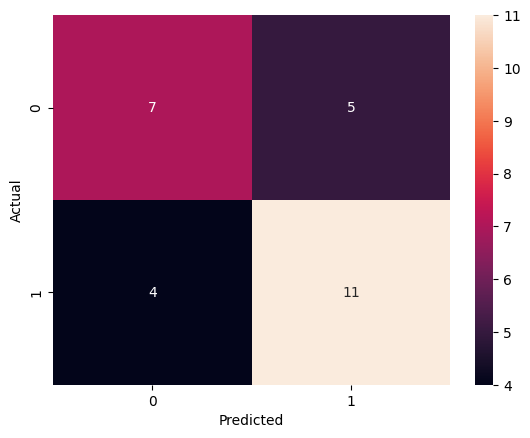

In [172]:

import seaborn as sns
sns.heatmap(matrix,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")